# Sequential Read: Run-to-Run Comparison

Two runs per (bs, iod) configuration. Run 1 timestamp: `1781541516`, Run 2 timestamps vary by block size (`1782338744` for bs16k/bs1m, `1782340230` for bs2m, `178234xxxx` for bs4k/bs4m).

### Key finding
- Small block sizes (4k, 16k): consistent within ±8% across runs.
- Large block sizes (1m, 2m, 4m): bimodal — some (bs, iod) cells hit a **~3.5 GB/s ceiling** with linearly scaling latency (serialized I/O), others reach **12–21 GB/s** with proportionally low latency (parallel I/O across DAOS targets).
- Which cells fall into which mode is **non-deterministic between runs**, suggesting it is driven by DAOS object placement (stripe layout) at write time.

In [2]:
import json, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from collections import defaultdict

DATA_DIR = "."

records = []
for f in glob.glob(f"{DATA_DIR}/fio_seq_read_*.json"):
    m = re.match(r".*/fio_seq_read_(bs\w+)_nj1_(iod\d+)_(\d+)\.json", f)
    if not m:
        continue
    bs, iod, ts = m.group(1), m.group(2), m.group(3)
    with open(f) as fh:
        d = json.load(fh)
    r = d['jobs'][0]['read']
    records.append({
        'bs': bs, 'iod': iod, 'ts': ts,
        'bw_GiBs': r['bw_bytes'] / 2**30,
        'iops': r['iops'],
        'lat_ms': r['lat_ns']['mean'] / 1e6,
    })

df = pd.DataFrame(records)

BS_ORDER  = ['bs4k', 'bs16k', 'bs1m', 'bs2m', 'bs4m']
IOD_ORDER = ['iod4', 'iod8', 'iod16', 'iod32', 'iod64', 'iod128', 'iod256']
df['bs']  = pd.Categorical(df['bs'],  categories=BS_ORDER,  ordered=True)
df['iod'] = pd.Categorical(df['iod'], categories=IOD_ORDER, ordered=True)
df = df.sort_values(['bs', 'iod', 'ts']).reset_index(drop=True)

# Assign run label (1 = older ts, 2 = newer ts)
df['run'] = df.groupby(['bs', 'iod'])['ts'].rank(method='dense').astype(int)
print(f"Total records: {len(df)}")
df.head(10)

Total records: 70


/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_39950/2617922493.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['run'] = df.groupby(['bs', 'iod'])['ts'].rank(method='dense').astype(int)


,bs,iod,ts,bw_GiBs,iops,lat_ms,run
0,bs4k,iod4,1781541516,0.099213,26008.066532,0.153463,1
1,bs4k,iod4,1782341158,0.100667,26389.160181,0.151289,2
2,bs4k,iod8,1781541516,0.141088,36985.483575,0.215977,1
3,bs4k,iod8,1782341250,0.145055,38025.316245,0.210046,2
4,bs4k,iod16,1781541516,0.175591,46030.182830,0.347251,1
5,bs4k,iod16,1782341344,0.179071,46942.300962,0.340552,2
6,bs4k,iod32,1781541516,0.271342,71130.764487,0.449502,1
7,bs4k,iod32,1782341437,0.275984,72347.444209,0.441999,2
8,bs4k,iod64,1781541516,0.305579,80105.729809,0.798557,1
9,bs4k,iod64,1782341530,0.311653,81697.871702,0.782954,2


## 1. BW difference heatmap (Run2 − Run1) / Run1

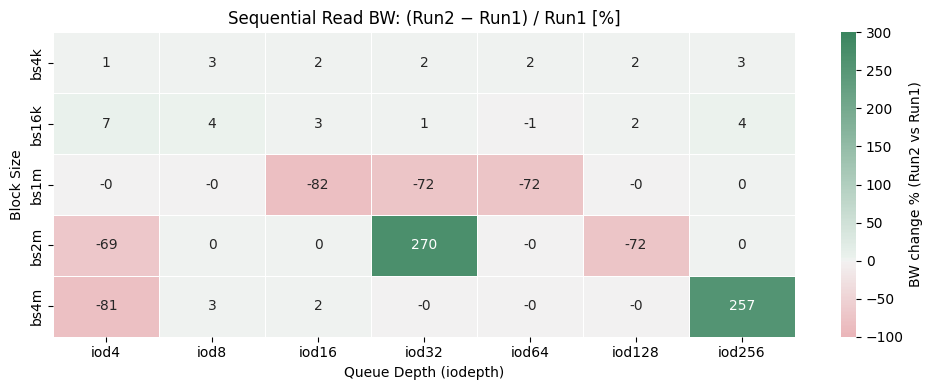

In [3]:
run1 = df[df['run'] == 1].set_index(['bs', 'iod'])['bw_GiBs']
run2 = df[df['run'] == 2].set_index(['bs', 'iod'])['bw_GiBs']
diff_pct = ((run2 - run1) / run1 * 100).unstack('iod')[IOD_ORDER]
diff_pct = diff_pct.reindex(BS_ORDER)

fig, ax = plt.subplots(figsize=(10, 4))
cmap = sns.diverging_palette(10, 145, as_cmap=True)
sns.heatmap(diff_pct, ax=ax, cmap=cmap, center=0, vmin=-100, vmax=300,
            annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': 'BW change % (Run2 vs Run1)'})
ax.set_title('Sequential Read BW: (Run2 − Run1) / Run1 [%]')
ax.set_xlabel('Queue Depth (iodepth)')
ax.set_ylabel('Block Size')
plt.tight_layout()
plt.savefig('seq_read_run_diff_heatmap.pdf', bbox_inches='tight')
plt.show()

## 2. Side-by-side BW heatmaps (Run 1 vs Run 2)

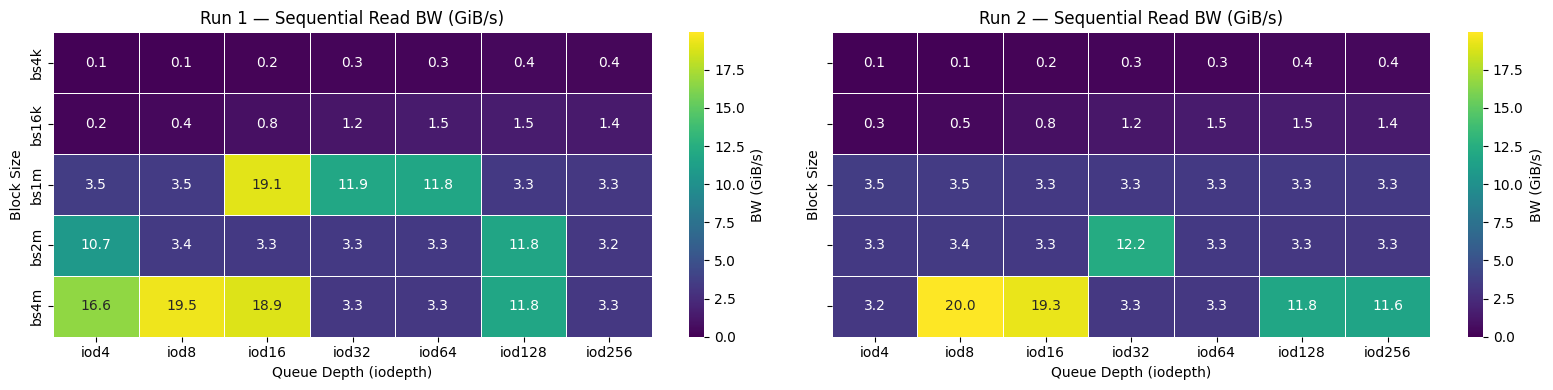

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

vmax = df['bw_GiBs'].max()

for run_id, ax in zip([1, 2], axes):
    pivot = (df[df['run'] == run_id]
             .pivot(index='bs', columns='iod', values='bw_GiBs')
             .reindex(index=BS_ORDER, columns=IOD_ORDER))
    sns.heatmap(pivot, ax=ax, cmap='viridis', vmin=0, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5,
                cbar_kws={'label': 'BW (GiB/s)'})
    ax.set_title(f'Run {run_id} — Sequential Read BW (GiB/s)')
    ax.set_xlabel('Queue Depth (iodepth)')
    ax.set_ylabel('Block Size')

plt.tight_layout()
plt.savefig('seq_read_run1_vs_run2_bw.pdf', bbox_inches='tight')
plt.show()

## 3. Side-by-side latency heatmaps (Run 1 vs Run 2)

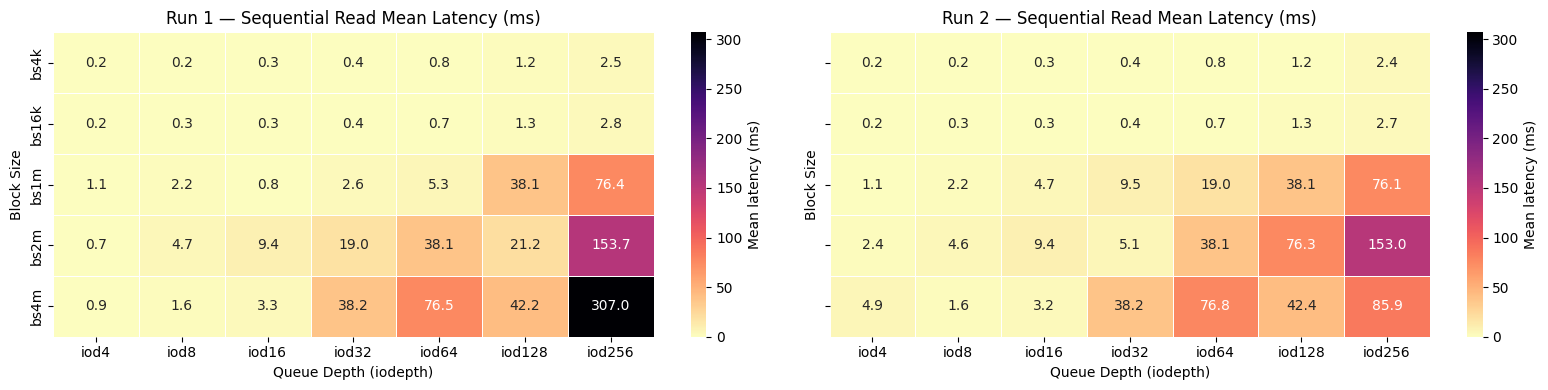

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

vmax_lat = df['lat_ms'].max()

for run_id, ax in zip([1, 2], axes):
    pivot = (df[df['run'] == run_id]
             .pivot(index='bs', columns='iod', values='lat_ms')
             .reindex(index=BS_ORDER, columns=IOD_ORDER))
    sns.heatmap(pivot, ax=ax, cmap='magma_r', vmin=0, vmax=vmax_lat,
                annot=True, fmt='.1f', linewidths=0.5,
                cbar_kws={'label': 'Mean latency (ms)'})
    ax.set_title(f'Run {run_id} — Sequential Read Mean Latency (ms)')
    ax.set_xlabel('Queue Depth (iodepth)')
    ax.set_ylabel('Block Size')

plt.tight_layout()
plt.savefig('seq_read_run1_vs_run2_lat.pdf', bbox_inches='tight')
plt.show()

## 4. Outlier deep-dive: serialized vs parallel I/O

For the ~3.5 GB/s ceiling cases, latency scales **linearly** with iodepth — indicating serialized I/O to a single DAOS target. For the high-BW cases, throughput is maintained while latency stays proportionally low — indicating parallel I/O across multiple targets.

Effective per-I/O latency = `lat_ms / iod` should be constant if I/Os are serialized.

In [6]:
# Extract iod number for calculations
df['iod_n'] = df['iod'].str.replace('iod', '').astype(int)
df['lat_per_io_ms'] = df['lat_ms'] / df['iod_n']
df['mode'] = df['bw_GiBs'].apply(lambda x: 'ceiling ~3.3' if x < 4.2 else ('HIGH >11' if x > 11 else 'mid 4-11'))

print("Outlier table (|diff| > 20%):")
print(f"{'BS':<8} {'IOD':<8} {'Run':<4} {'BW GiB/s':>10} {'Lat ms':>10} {'Lat/IO ms':>12} {'Mode'}")
print("-" * 65)

pairs = df.groupby(['bs', 'iod'])
for (bs, iod), g in pairs:
    if len(g) < 2:
        continue
    g = g.sort_values('run')
    bws = g['bw_GiBs'].values
    diff = (bws[1] - bws[0]) / bws[0] * 100
    if abs(diff) > 20:
        for _, row in g.iterrows():
            print(f"{row['bs']:<8} {row['iod']:<8} {int(row['run']):<4} {row['bw_GiBs']:>10.2f} {row['lat_ms']:>10.1f} {row['lat_per_io_ms']:>12.2f}  {row['mode']}")
        print(f"{'':8} {'':8} {'diff':>4} {diff:>+10.1f}%")
        print()

Outlier table (|diff| > 20%):
BS       IOD      Run    BW GiB/s     Lat ms    Lat/IO ms Mode
-----------------------------------------------------------------
bs1m     iod16    1         19.08        0.8         0.05  HIGH >11
bs1m     iod16    2          3.34        4.7         0.29  ceiling ~3.3
                  diff      -82.5%

bs1m     iod32    1         11.91        2.6         0.08  HIGH >11
bs1m     iod32    2          3.30        9.5         0.30  ceiling ~3.3
                  diff      -72.3%

bs1m     iod64    1         11.79        5.3         0.08  HIGH >11
bs1m     iod64    2          3.28       19.0         0.30  ceiling ~3.3
                  diff      -72.2%

bs2m     iod4     1         10.74        0.7         0.18  mid 4-11
bs2m     iod4     2          3.31        2.4         0.59  ceiling ~3.3
                  diff      -69.2%

bs2m     iod32    1          3.29       19.0         0.59  ceiling ~3.3
bs2m     iod32    2         12.16        5.1         0.16  HIGH >

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_39950/3752881989.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pairs = df.groupby(['bs', 'iod'])


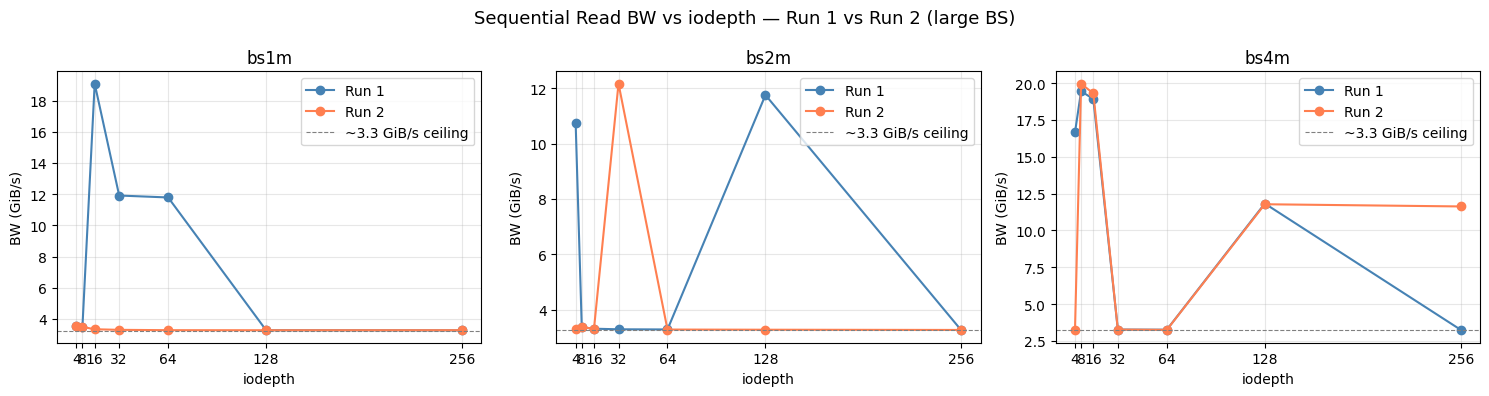

In [7]:
# Latency-per-IO scatter for large BS to visualize serialized vs parallel
large_bs = df[df['bs'].isin(['bs1m', 'bs2m', 'bs4m'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

colors = {1: 'steelblue', 2: 'coral'}
for ax, bs in zip(axes, ['bs1m', 'bs2m', 'bs4m']):
    sub = large_bs[large_bs['bs'] == bs]
    for run_id, grp in sub.groupby('run'):
        grp = grp.sort_values('iod_n')
        ax.plot(grp['iod_n'], grp['bw_GiBs'], marker='o', label=f'Run {run_id}',
                color=colors[run_id])
    ax.axhline(3.26, color='gray', linestyle='--', linewidth=0.8, label='~3.3 GiB/s ceiling')
    ax.set_title(bs)
    ax.set_xlabel('iodepth')
    ax.set_ylabel('BW (GiB/s)')
    ax.set_xticks(sub['iod_n'].unique())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Sequential Read BW vs iodepth — Run 1 vs Run 2 (large BS)', fontsize=13)
plt.tight_layout()
plt.savefig('seq_read_large_bs_line.pdf', bbox_inches='tight')
plt.show()

## 5. Interpretation

| Observation | Value |
|---|---|
| Consistent BW ceiling | ~3.5 GB/s |
| Peak observed BW | ~21 GB/s (bs4m, iod8/iod16) |
| Ceiling latency scaling | Linear with iodepth (serialized) |
| High-BW latency scaling | Sub-linear or flat (parallel) |

**Hypothesis:** The ~3.5 GB/s ceiling corresponds to I/O serialized through a single DAOS target or a single client-side fetch thread. The high-BW cases (12–21 GB/s) reflect I/O parallelized across multiple DAOS targets, driven by how fio's objects happen to be striped at write time.

**Why run-to-run inconsistency?** Each run writes a fresh dataset; DAOS object placement (target selection) is non-deterministic. Some placements stripe data across many targets (fast), others concentrate it (ceiling). The cells that differ between runs correspond to `(bs, iod)` combinations near a tipping point in object count or stripe width.

**Recommended next steps:**
- Check DAOS pool target count and the number of DFS chunks per fio file.
- Fix the DAOS object class (e.g., `OC_SX` vs `OC_EC_nP1`) explicitly in fio or the DFS container config to remove placement randomness.
- Re-run with multiple repetitions and report median/min/max to characterize the distribution.

## 6. Side-by-side bar chart: BW Run 1 vs Run 2

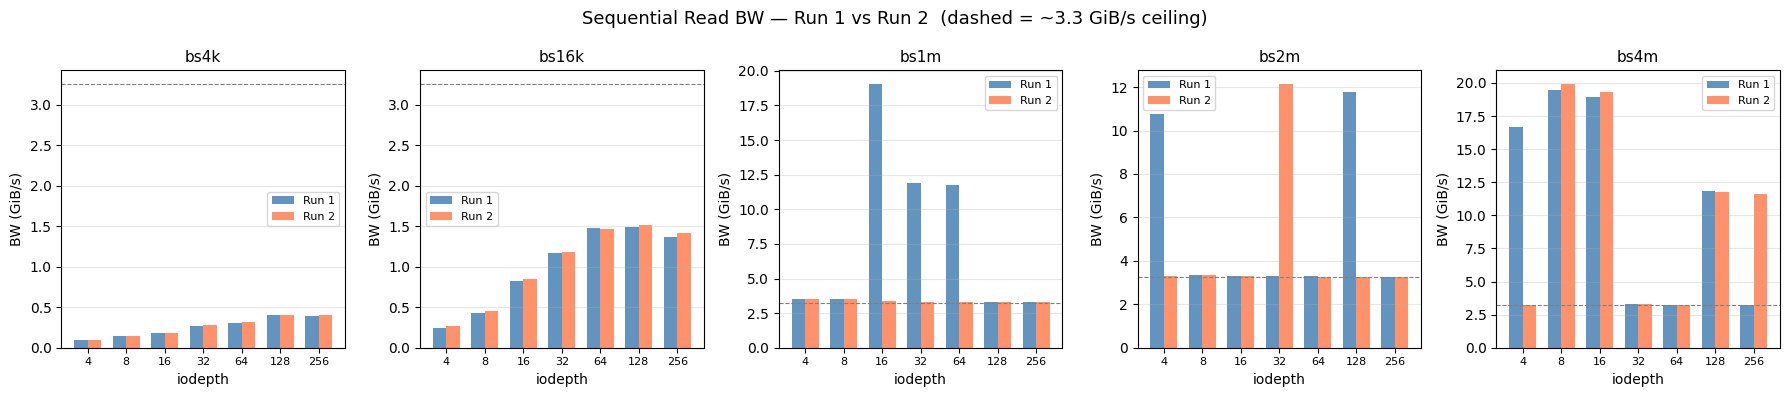

In [8]:
fig, axes = plt.subplots(1, len(BS_ORDER), figsize=(18, 4), sharey=False)

bar_width = 0.35
iod_nums = [int(i.replace('iod', '')) for i in IOD_ORDER]
x = np.arange(len(IOD_ORDER))
colors = {1: 'steelblue', 2: 'coral'}

for ax, bs in zip(axes, BS_ORDER):
    for run_id, offset in [(1, -bar_width / 2), (2, bar_width / 2)]:
        vals = (df[(df['run'] == run_id) & (df['bs'] == bs)]
                .set_index('iod')
                .reindex(IOD_ORDER)['bw_GiBs']
                .values)
        ax.bar(x + offset, vals, width=bar_width,
               label=f'Run {run_id}', color=colors[run_id], alpha=0.85)

    ax.set_title(bs, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in iod_nums], fontsize=8)
    ax.set_xlabel('iodepth')
    ax.set_ylabel('BW (GiB/s)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(3.26, color='gray', linestyle='--', linewidth=0.8)

fig.suptitle('Sequential Read BW — Run 1 vs Run 2  (dashed = ~3.3 GiB/s ceiling)', fontsize=13)
plt.tight_layout()
plt.savefig('seq_read_bar_run1_vs_run2.pdf', bbox_inches='tight')
plt.show()